In [1]:
import torch
import torch.nn as nn

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        """
        latent_dim: 输入噪声向量的维度
        img_dim: 输出图片的维度（28*28=784 for MNIST）
        """
        super().__init__()
        self.net = nn.Sequential(
            # 第一层：噪声 → 256
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            # 第二层：256 → 512
            nn.Linear(256, 512),
            nn.ReLU(True),
            # 第三层：512 → 1024
            nn.Linear(512, 1024),
            nn.ReLU(True),
            # 输出层：1024 → 图片维度
            nn.Linear(1024, img_dim),
            nn.Tanh()  # 输出范围 [-1, 1]
        )

    def forward(self, z):
        """z: (batch_size, latent_dim) 的随机噪声"""
        return self.net(z)

In [3]:
class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        """
        img_dim: 输入图片的维度（28*28=784 for MNIST）
        """
        super().__init__()
        self.net = nn.Sequential(
            # 第一层：图片维度 → 1024
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2, True),
            nn.Dropout(0.3),
            # 第二层：1024 → 512
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, True),
            nn.Dropout(0.3),
            # 第三层：512 → 256
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, True),
            nn.Dropout(0.3),
            # 输出层：256 → 1
            nn.Linear(256, 1),
            nn.Sigmoid()  # 输出概率 [0, 1]
        )

    def forward(self, img):
        """img: (batch_size, img_dim) 的图片"""
        return self.net(img)

In [4]:
latent_dim = 100
img_dim = 784
lr = 0.0002
batch_size = 64
num_epochs = 50

In [5]:
G = Generator(latent_dim, img_dim)
D = Discriminator(img_dim)

In [6]:
from torch.optim import Adam

In [7]:
opt_G = Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [8]:
criterion = nn.BCELoss()

In [9]:
fixed_z = torch.randn(16, latent_dim)

In [ ]:
# for epoch in range(num_epochs):
#     for i, (real_imgs, _) in enumerate(dataloader):
#         real_imgs = real_imgs.view(-1, img_dim)
#         bs = real_imgs.size(0)
#
#         real_labels = torch.ones(bs, 1)
#         fake_labels = torch.zeros(bs, 1)
#
#         z = torch.randn(bs, latent_dim)
#         fake_imgs = G(z).detach()
#
#         loss_real = criterion(D(real_imgs), real_labels)
#         loss_fake = criterion(D(fake_imgs), fake_labels)
#
#         loss_D = (loss_real + loss_fake) / 2
#
#         opt_D.zero_grad()
#         loss_D.backward()
#         opt_D.step()
#
#         z = torch.randn(bs, latent_dim)
#         fake_imgs = G(z)
#
#         loss_G = criterion(D(fake_imgs), real_labels)
#
#         opt_G.zero_grad()
#         loss_G.backward()
#         opt_G.step()
#
#     print(f"Epoch [{epoch+1}/{num_epochs}]  "
#           f"Loss_D: {loss_D.item():.4f}  "
#           f"Loss_G: {loss_G.item():.4f}")

使用设备: cuda
Epoch [1/50]  Loss_D: 0.1252  Loss_G: 5.6149
Epoch [2/50]  Loss_D: 0.3331  Loss_G: 3.5306
Epoch [3/50]  Loss_D: 0.2141  Loss_G: 5.1374
Epoch [4/50]  Loss_D: 0.0681  Loss_G: 4.6322
Epoch [5/50]  Loss_D: 0.0005  Loss_G: 9.6042


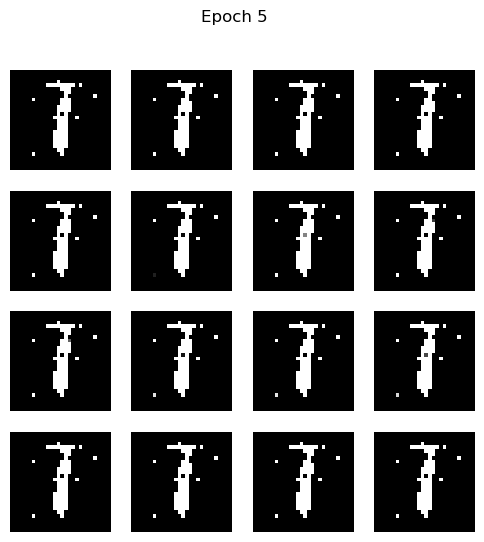

Epoch [6/50]  Loss_D: 0.0000  Loss_G: 11.2092
Epoch [7/50]  Loss_D: 0.0000  Loss_G: 10.0840
Epoch [8/50]  Loss_D: 0.0290  Loss_G: 5.2107
Epoch [9/50]  Loss_D: 0.0001  Loss_G: 10.1757
Epoch [10/50]  Loss_D: 0.0002  Loss_G: 12.5784


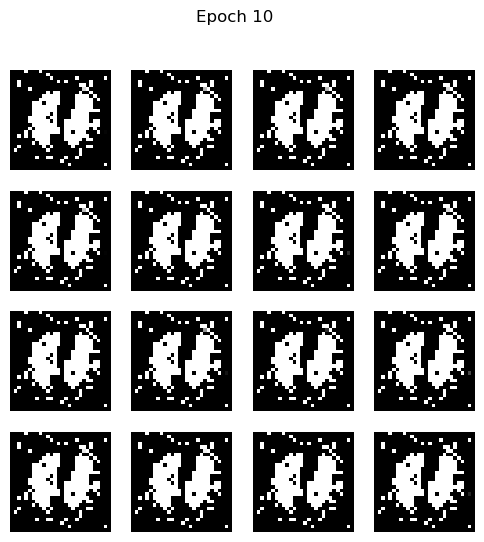

Epoch [11/50]  Loss_D: 0.0000  Loss_G: 11.1581
Epoch [12/50]  Loss_D: 0.0000  Loss_G: 13.6867
Epoch [13/50]  Loss_D: 0.0001  Loss_G: 9.9973
Epoch [14/50]  Loss_D: 50.0000  Loss_G: 0.0000
Epoch [15/50]  Loss_D: 50.0000  Loss_G: 0.0000


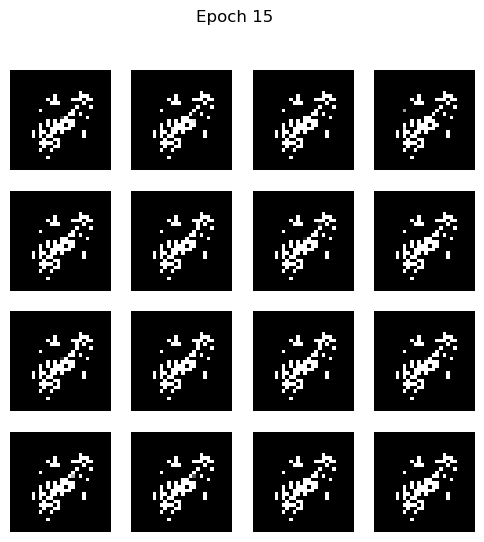

Epoch [16/50]  Loss_D: 50.0000  Loss_G: 0.0000


In [ ]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 剩下所有业务代码

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ---------------------- 设备自动选择 GPU/CPU ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ---------------------- 模型定义 ----------------------
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()  # [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2, True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)

# ---------------------- 构建 dataloader ----------------------
batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # [0,1] → [-1,1]
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=0   # Windows下建议0，Linux可以调大
)

# ---------------------- 超参数 & 初始化，模型移到GPU ----------------------
latent_dim = 100
img_dim = 784
lr = 0.0002
num_epochs = 50

G = Generator(latent_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

opt_G = Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

criterion = nn.BCELoss()
fixed_z = torch.randn(16, latent_dim).to(device)   # 固定噪声也要上GPU

# ---------------------- 训练循环 ----------------------
for epoch in range(num_epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.view(-1, img_dim).to(device)  # 数据送入GPU
        bs = real_imgs.size(0)

        # 标签也要放到GPU
        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)

        # ===== 训练判别器 =====
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G(z).detach()

        loss_real = criterion(D(real_imgs), real_labels)
        loss_fake = criterion(D(fake_imgs), fake_labels)
        loss_D = (loss_real + loss_fake) / 2

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ===== 训练生成器 =====
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G(z)
        loss_G = criterion(D(fake_imgs), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")

    # 每5轮可视化生成图片
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            gen_imgs = G(fixed_z).view(-1, 28, 28).cpu()  # 画图要搬回CPU
        fig, axes = plt.subplots(4, 4, figsize=(6, 6))
        for idx, ax in enumerate(axes.flatten()):
            ax.imshow(gen_imgs[idx], cmap="gray")
            ax.axis("off")
        plt.suptitle(f"Epoch {epoch+1}")
        plt.show()